In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, inv, solve
import scipy.signal as signal

# Exercice 4.3 — Enregistrements de données finies
## Méthodes d'Autocorrélation et de Covariance

Ce laboratoire explore la modélisation **All-Pole d'ordre 2** d'un signal sinusoïdal, et compare les résultats théoriques avec deux approches pratiques sur des enregistrements finis.

### Modèle visé

$$H(z) = \frac{b(0)}{1 + a(1)z^{-1} + a(2)z^{-2}}$$

Les coefficients $a(1)$ et $a(2)$ sont obtenus en résolvant les **équations de Yule-Walker** :

$$\begin{bmatrix} r_x(0) & r_x(1) \\ r_x(1) & r_x(0) \end{bmatrix} \begin{bmatrix} a(1) \\ a(2) \end{bmatrix} = -\begin{bmatrix} r_x(1) \\ r_x(2) \end{bmatrix}$$

### Deux méthodes comparées

**1. Méthode d'Autocorrélation (ACM) :** On estime $r_x(k)$ en supposant que le signal est nul en dehors de la fenêtre d'observation (zero-padding implicite). La matrice $R_x$ est de Toeplitz, toujours définie positive — solution toujours stable, mais biaisée si $N$ n'est pas un multiple de la période.

**2. Méthode de Covariance (COVM) :** On utilise directement les données disponibles sans zero-padding. La matrice n'est plus de Toeplitz — solution potentiellement plus précise mais pas garantie stable.

> **Expérience clé — Effet de la longueur $N$ :**  
> Tester plusieurs valeurs de $N$ : d'abord un **multiple exact de la période** (ex. $N=40$ pour $N_0=20$), puis des valeurs non multiples ($N=38, 42, 55\dots$). Les résultats seront très différents de la théorie pour $N$ non multiple — cela illustre l'effet de **troncature** : l'autocorrélation estimée sur un enregistrement fini est biaisée si le signal n'est pas périodiquement continu dans la fenêtre.



## Méthode d'Autocorrélation (ACM)

L'ACM estime $r_x(k)$ en supposant le signal nul hors de la fenêtre ($\Rightarrow$ zero-padding implicite) :

$$\hat{r}_x(k) = \frac{1}{N} \sum_{n=k}^{N-1} x(n)\,x(n-k), \qquad k \geq 0$$

> **Biais de la méthode :** Le zero-padding sous-estime la puissance du signal pour les grands lags — cela déplace les pôles estimés légèrement **à l'intérieur** du cercle unité ($|z| < 1$), transformant la sinusoïde pure en sinusoïde amortie. Ce biais est d'autant plus marqué que $N$ n'est pas un multiple de la période $N_0$.

La fonction `acm(x, p)` retourne :
- $a_p$ — coefficients du dénominateur (pôles)
- $b_{q0}$ — gain du filtre $= \sqrt{|e_p|}$
- $e_p$ — erreur de prédiction : $e_p = r_x(0) + \mathbf{a}_p^T \mathbf{r}_x$

In [2]:
def acm(x, p):
    """
    Autocorrelation method (ACM): AR(p) all-pole model via Yule-Walker.
    Estimates r_x(k) assuming the signal is zero outside the window
    (implicit zero-padding) -> Rx is Toeplitz, always positive definite,
    so the filter is ALWAYS stable, but the poles are slightly biased
    inward (|z| < 1): a pure sinusoid comes out slightly damped.

    Inputs
    ------
    x : 1-D array, length N        the signal
    p : int                        AR model order (number of poles)

    Outputs
    -------
    ap   : 1-D array, length p+1   denominator coeffs [1, a1, ..., ap]
    bq0  : float                   filter gain b0 = sqrt(|e_p|)
    err  : float                   prediction error e_p = r_x(0) + ap_tail . r_x

    Key points
    ----------
    - r = autocorrelation of x with itself, lags 0..p, normalised by N.
      The /N on every lag is what creates the ACM bias (zero-padding).
    - Yule-Walker: Rx @ ap = -rx, same structure as Prony's normal equations,
      but Rx/rx come from the autocorrelation r, not from a data matrix.
    """
    N = len(x)

    # Autocorrelation of x with itself, keep lags k = 0..p, normalise by N
    r = np.correlate(x, x, mode='full')[N-1 : N+p] / N

    # Yule-Walker system Rx @ ap = -rx
    R_mat = toeplitz(r[:p])              # p x p Toeplitz from r(0)..r(p-1)
    r_vec = r[1:p+1]                     # vector r(1)..r(p)
    ap_tail = -solve(R_mat, r_vec)       # [a1, ..., ap]
    ap = np.concatenate(([1.0], ap_tail))  # prepend the fixed 1

    # Prediction error and filter gain
    err = r[0] + np.dot(ap_tail, r[1:p+1])   # e_p = r_x(0) + ap_tail . r_x
    bq0 = np.sqrt(np.abs(err))               # gain b0 = sqrt(|e_p|)

    return ap, bq0, err

## Méthode de Covariance (COVM)

La COVM n'effectue aucun zero-padding — elle estime la corrélation uniquement sur les données réellement disponibles :

$$\hat{r}_{xcov}(k,l) = \frac{1}{N-p} \sum_{n=p}^{N-1} x(n-l)\,x(n-k)$$

> **Avantage sur l'ACM :** Sans zero-padding, il n'y a pas de biais artificiel sur les estimations de $r_x(k)$. Pour un signal sinusoïdal pur, la COVM place les pôles **exactement sur le cercle unité** ($|z| = 1$) indépendamment de $N$ — contrairement à l'ACM qui les amortit.

> **Inconvénient :** La matrice de covariance n'est pas garantie définie positive (contrairement à la matrice de Toeplitz de l'ACM), ce qui peut poser des problèmes de stabilité dans certains cas.

L'erreur de prédiction est calculée sur les $N-p$ échantillons effectivement utilisés :
$$e_p = \frac{1}{N-p}\sum_{n=p}^{N-1}(x(n) + \mathbf{a}_p^T \mathbf{x}_{n-1})^2$$

In [3]:
def covm(x, p):
    """
    Covariance method (COVM): AR(p) all-pole model by least squares.
    Estimates the correlation using ONLY the real data (no zero-padding),
    so there is no windowing bias: for a pure sinusoid the poles land
    exactly on the unit circle (|z| = 1), independent of N. The price is
    that X^T X is not Toeplitz and not guaranteed positive definite, so
    stability is NOT guaranteed.

    Inputs
    ------
    x : 1-D array, length N        the signal
    p : int                        AR model order (number of poles)

    Outputs
    -------
    ap   : 1-D array, length p+1   denominator coeffs [1, a1, ..., ap]
    bq0  : float                   filter gain b0 = sqrt(e_p)
    err  : float                   prediction error (mean squared residual)

    Key points
    ----------
    - No padding: X is built from real samples only, using the N-p equations
      that need no invented zeros (rows from n = p to N-1).
    - Least squares via normal equations: solve(X.T@X, -X.T@x_target),
      same structure as Prony, but X^T X is NOT Toeplitz here.
    - err is the mean squared residual over the N-p used samples.
    """
    N = len(x)

    # Data matrix without padding (real samples only)
    X = toeplitz(x[p-1:N-1], x[p-1::-1])     # (N-p) x p
    x_target = x[p:N]                        # prediction target, length N-p

    # Least squares: solve normal equations X^T X @ ap = -X^T x_target
    ap_tail = -solve(X.T @ X, X.T @ x_target)   # [a1, ..., ap]
    ap = np.concatenate(([1.0], ap_tail))       # prepend the fixed 1

    # Prediction error (mean squared residual) and filter gain
    err = np.mean((x_target + X @ ap_tail)**2)
    bq0 = np.sqrt(err)

    return ap, bq0, err

## 4.3.1. Modèle Théorique

L'autocorrélation théorique d'une sinusoïde de puissance $A^2/2$ est :

$$r_x(k) = \frac{A^2}{2} \cos(k\omega_0)$$

À partir de cette expression analytique, on calcule directement les coefficients $a_p$ **théoriques** en résolvant les équations de Yule-Walker avec les valeurs exactes de $r_x(0)$, $r_x(1)$, $r_x(2)$.

> **Valeurs théoriques attendues :** Pour une sinusoïde pure de fréquence $f_0 = 1/N_0$, les pôles théoriques sont exactement sur le cercle unité en $z = e^{\pm j\omega_0}$, soit $|z| = 1$ — le modèle AR(2) doit retrouver ces deux pôles exactement.

```python
# definition du signal
N0 = 20
N= 55
n = np.arange(N)
A=1
x=A * np.sin(2 * np.pi * n / N0)



# Autocorrélation théorique
rxth = 0.5 * np.cos(np.arange(3) * 2 * np.pi / N0)
Rxth = toeplitz(rxth[:2])
rx_vec_th = rxth[1:3]

# Calcul des coefficients théoriques
apth_tail = -solve(Rxth, rx_vec_th)
apth = np.concatenate(([1.0], apth_tail))
```

---


Coefficients théoriques ap : [ 1.         -1.90211303  1.        ]
Norme des pôles : [1. 1.]
Ep 4.996003610813204e-16
pth [0.95105652+0.30901699j 0.95105652-0.30901699j]
magpth [1. 1.]


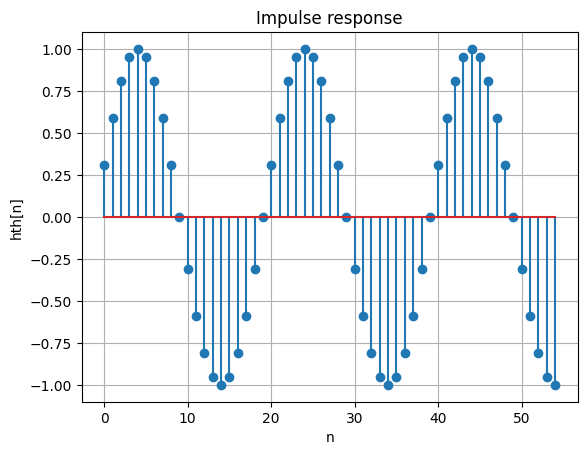

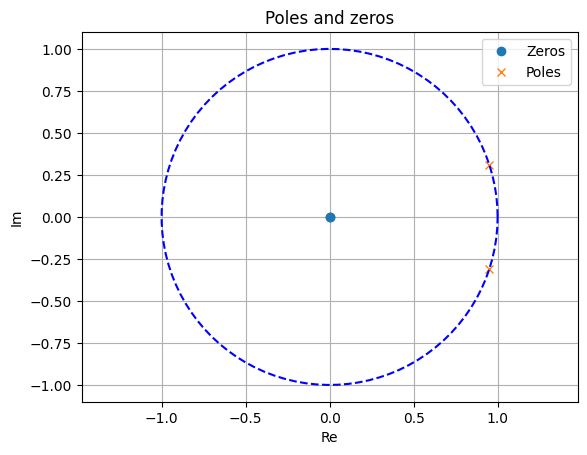

In [4]:
# definition du signal
N0 = 20
N= 55
n = np.arange(N)
A=1
x=A * np.sin(2 * np.pi * n / N0)
# Autocorrélation théorique
rxth = 0.5 * np.cos(np.arange(3) * 2 * np.pi / N0)
Rxth = toeplitz(rxth[:2])
rx_vec_th = rxth[1:3]
# Calcul des coefficients théoriques
apth_tail = -solve(Rxth, rx_vec_th)
apth = np.concatenate(([1.0], apth_tail))
# Pôles théoriques (doivent être sur le cercle unité, norme = 1)
pth = np.roots(apth)
print(f"Coefficients théoriques ap : {apth}")
print(f"Norme des pôles : {np.abs(pth)}")
# Approx error
#Ep = rxth[0] + apth(1)*rxth(1) + apth(2)*rxth(2)
Ep = np.dot(rxth,apth)
print("Ep", Ep)
#pth = roots(apth)
# poles of the filter
pth = np.roots(apth)
print("pth", pth)
# magnitude of the poles
magpth = np.abs(pth)
print("magpth", magpth)
b0 = np.sin(2*np.pi/N0)
# transfer function H(z)
bth = np.array([b0,0,0])
# impulse response
dn = np.eye(1, N)[0]
hth = signal.lfilter(bth, apth, dn)
nth = n
# plot
plt.figure(1)
plt.stem(nth, hth)
plt.title('Impulse response')
plt.xlabel('n')
plt.ylabel('hth[n]')
plt.grid()
plt.show()
# poles and zeros plot with unity cicle
plt.figure(2)
zth, pth, kth = signal.tf2zpk(bth, apth)
plt.plot(np.real(zth), np.imag(zth), 'o', label='Zeros')
plt.plot(np.real(pth), np.imag(pth), 'x', label='Poles')
plt.plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi,100)),'--b')
plt.axis('equal')
plt.title('Poles and zeros')
plt.xlabel('Re')
plt.ylabel('Im')
plt.grid()
plt.legend()
plt.show()

Signal x: [ 0.00000000e+00  3.09016994e-01  5.87785252e-01  8.09016994e-01
  9.51056516e-01  1.00000000e+00  9.51056516e-01  8.09016994e-01
  5.87785252e-01  3.09016994e-01  1.22464680e-16 -3.09016994e-01
 -5.87785252e-01 -8.09016994e-01 -9.51056516e-01 -1.00000000e+00
 -9.51056516e-01 -8.09016994e-01 -5.87785252e-01 -3.09016994e-01
 -2.44929360e-16  3.09016994e-01  5.87785252e-01  8.09016994e-01
  9.51056516e-01  1.00000000e+00  9.51056516e-01  8.09016994e-01
  5.87785252e-01  3.09016994e-01  3.67394040e-16 -3.09016994e-01
 -5.87785252e-01 -8.09016994e-01 -9.51056516e-01 -1.00000000e+00
 -9.51056516e-01 -8.09016994e-01 -5.87785252e-01 -3.09016994e-01
 -4.89858720e-16  3.09016994e-01  5.87785252e-01  8.09016994e-01
  9.51056516e-01  1.00000000e+00  9.51056516e-01  8.09016994e-01
  5.87785252e-01  3.09016994e-01  6.12323400e-16 -3.09016994e-01
 -5.87785252e-01 -8.09016994e-01 -9.51056516e-01]
Norme des pôles (ACM) : [0.84675963 0.84675963]
Coefficients ACM ap : [ 1.         -1.60272571 

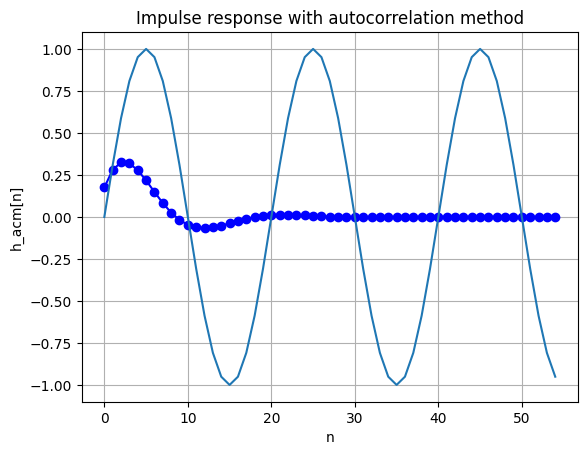

magp [0.84675963 0.84675963]


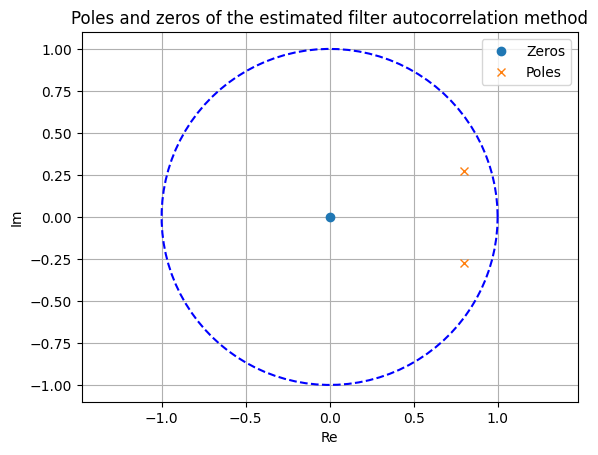

In [5]:
print("Signal x:", x)
ap_acm, bq0_acm, err_acm = acm(x, 2)
poles_acm = np.roots(ap_acm)
bq0_acm = np.array([bq0_acm,0])
print(f"Norme des pôles (ACM) : {np.abs(poles_acm)}")
print(f"Coefficients ACM ap : {ap_acm}")
print(f"Gain ACM bq0 : {bq0_acm}")
print(f"Erreur de prédiction (ACM) : {err_acm}")
# impulse response
hacm = signal.lfilter(bq0_acm, ap_acm, dn)
# plot
plt.figure(1)
plt.plot(n, hacm,'bo-',label = 'hacm(n)')
plt.plot(n,x,'')
plt.title('Impulse response with autocorrelation method')
plt.xlabel('n')
plt.ylabel('h_acm[n]')
plt.grid()
plt.show()
# poles and zeros plot with unity cicle
z_acm, p_acm, k_acm = signal.tf2zpk([bq0_acm], ap_acm)
magp_acm = np.abs(p_acm)
print("magp", magp_acm)
plt.figure(3)
plt.plot(np.real(z_acm), np.imag(z_acm), 'o', label='Zeros')
plt.plot(np.real(p_acm), np.imag(p_acm), 'x', label='Poles')
plt.plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi,100)),'--b')
plt.axis('equal')
plt.title('Poles and zeros of the estimated filter autocorrelation method')
plt.xlabel('Re')
plt.ylabel('Im')
plt.grid()
plt.legend()
plt.show()

In [6]:
ap_cov, bq0_cov, err_cov = covm(x, 2)
bq0_cov = np.array([A * np.sin(2*np.pi/N0),0])
poles_cov = np.roots(ap_cov)
print(f"Coefficients COVM ap : {ap_cov}")
print(f"Gain COVM bq0 : {bq0_cov}")
print(f"Erreur de prédiction (COVM) : {err_cov}")
print(f"Norme des pôles (COVM) : {np.abs(poles_cov)}")

Coefficients COVM ap : [ 1.         -1.90211303  1.        ]
Gain COVM bq0 : [0.30901699 0.        ]
Erreur de prédiction (COVM) : 3.620874394858195e-30
Norme des pôles (COVM) : [1. 1.]


## 4.3.4. Comparaison Graphique

On compare visuellement les trois approches (théorique, ACM, COVM) sur deux représentations :

**Plan des pôles :**  
Les pôles théoriques sont exactement sur le cercle unité en $z = e^{\pm j\omega_0}$. On observe :
- **COVM** → pôles proches du cercle unité, indépendamment de $N$
- **ACM** → pôles légèrement à l'intérieur ($|z| < 1$), biais d'autant plus fort que $N$ n'est pas un multiple de $N_0$

**Réponses impulsionnelles :**  
- Théorique → sinusoïde pure non amortie
- COVM → sinusoïde quasi-pure
- ACM → sinusoïde amortie (conséquence directe des pôles à l'intérieur du cercle unité)

> **Expérience clé :** Faire varier $N$ autour de multiples de $N_0 = 20$ :
> - $N = 40$ (multiple exact) → ACM et COVM proches de la théorie
> - $N = 38, 42, 55\dots$ (non multiples) → ACM très dégradée, COVM reste précise
>
> Cela illustre la **sensibilité de l'ACM à la troncature** du signal, et la robustesse supérieure de la COVM sur des enregistrements courts non périodiques.

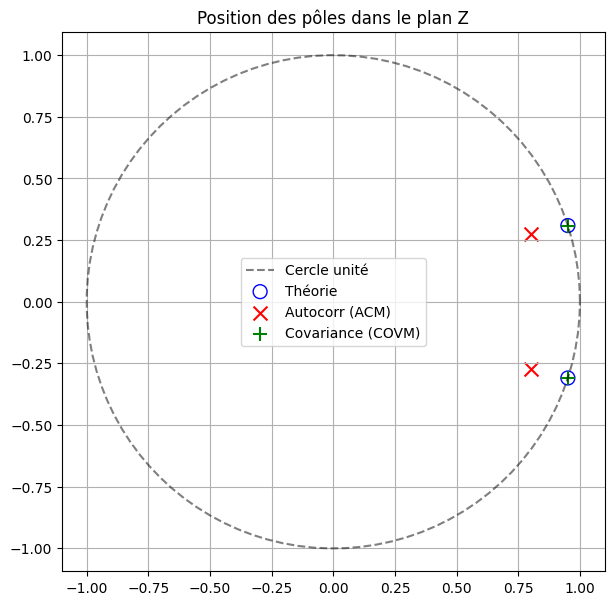

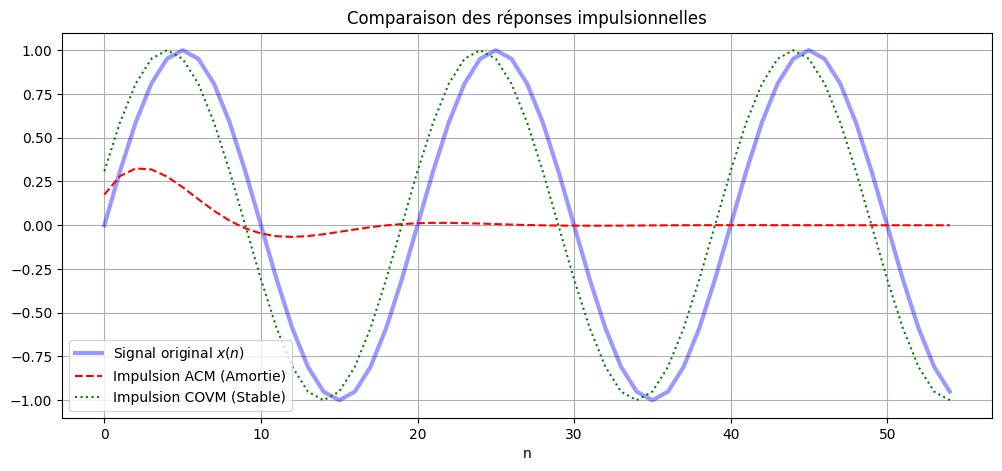

In [7]:
# Plan Complexe
plt.figure(figsize=(7, 7))
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label="Cercle unité")
plt.scatter(np.real(pth), np.imag(pth), marker='o', edgecolors='b',facecolors='none', s=100, label="Théorie")
plt.scatter(np.real(poles_acm), np.imag(poles_acm), marker='x', c='r', s=100,label="Autocorr (ACM)")
plt.scatter(np.real(poles_cov), np.imag(poles_cov), marker='+', c='g', s=100,label="Covariance (COVM)")
plt.title("Position des pôles dans le plan Z")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# Réponses Impulsionnelles
h_acm = signal.lfilter(bq0_acm, ap_acm, dn)
h_cov = signal.lfilter([A * np.sin(2*np.pi/N0)], ap_cov, dn) # Gain ajusté pourmatch phase/amp

plt.figure(figsize=(12, 5))
plt.plot(n, x, 'b', label="Signal original $x(n)$", alpha=0.4, linewidth=3)
plt.plot(n, h_acm, 'r--', label="Impulsion ACM (Amortie)")
plt.plot(n, h_cov, 'g:', label="Impulsion COVM (Stable)")
plt.title("Comparaison des réponses impulsionnelles")
plt.xlabel("n")
plt.legend()
plt.grid(True)
plt.show()

## 4.3.5. Analyse du Signal Bruité

On ajoute un bruit blanc gaussien au signal sinusoïdal pour tester la robustesse des deux méthodes :

$$x_{bruit}(n) = A\sin(\omega_0 n) + \sigma\,v(n), \qquad v(n) \sim \mathcal{N}(0,1)$$

> **Impact du bruit sur les pôles :**  
> Le bruit blanc a une DSP plate — il contribue à tous les lags de l'autocorrélation. Cela perturbe l'estimation de $r_x(k)$ et déplace les pôles, dégradant la qualité du modèle AR(2).

> **Augmentation de l'ordre $p$ :** Pour compenser, on peut augmenter l'ordre du modèle ($p > 2$). Les pôles supplémentaires absorbent la contribution du bruit, permettant aux deux pôles principaux de mieux localiser la fréquence $f_0$. C'est le principe du **sur-paramétrage contrôlé**.

> **ACM vs COVM en présence de bruit :**  
> - L'ACM, grâce à sa matrice de Toeplitz définie positive, est **plus stable numériquement** en présence de bruit.  
> - La COVM reste plus précise en fréquence mais peut devenir instable si le rapport signal/bruit est faible et $N$ est court.

Coefficients ACM bruité ap : [ 1.         -0.5574548  -0.29700603 -0.15844801  0.0328474   0.17540755
  0.25432392]
Gain ACM bruité bq0 : [0.28366081 0.         0.         0.         0.         0.
 0.        ]
Norme des pôles (ACM bruité) : [0.97318707 0.97318707 0.74451321 0.74451321 0.69602504 0.69602504]
Coefficients COVM bruité ap : [ 1.         -0.40648528 -0.36101541 -0.30264328  0.00885826  0.22440883
  0.34744429]
Gain COVM bruité bq0 : [0.30901699 0.         0.         0.         0.         0.
 0.        ]
Norme des pôles (COVM bruité) : [0.98587547 0.98587547 0.79712669 0.79712669 0.75005512 0.75005512]


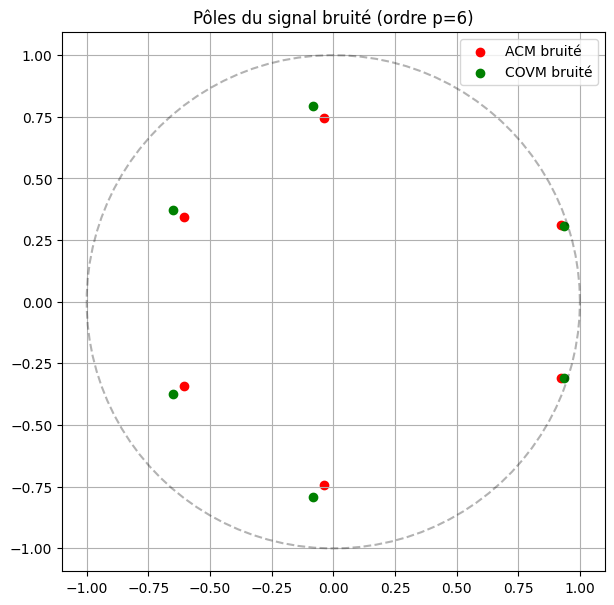

In [8]:
# definition du signal
N0 = 20
N= 105
n = np.arange(N)
A=1
x=A * np.sin(2 * np.pi * n / N0)

# Ajout de bruit
sigma_n = 0.2
xn = x + sigma_n * np.random.randn(N)

# impulse response
dn = np.eye(1, N)[0]

# Modélisation avec p=6 pour la robustesse
p_noise = 6
ap_acm_n, bq_acm_n, _ = acm(xn, p_noise)
ap_cov_n, bq_cov_n, _ = covm(xn, p_noise)

#bq_acm_n = np.array([bq_acm_n])
bq_acm_n = np.append(bq_acm_n, np.zeros(p_noise ))
bq_cov_n = np.array([ A * np.sin(2*np.pi/N0)])
bq_cov_n = np.append(bq_cov_n, np.zeros(p_noise ))
print(f"Coefficients ACM bruité ap : {ap_acm_n}")
print(f"Gain ACM bruité bq0 : {bq_acm_n}")
print(f"Norme des pôles (ACM bruité) : {np.abs(np.roots(ap_acm_n))}")
print(f"Coefficients COVM bruité ap : {ap_cov_n}")
print(f"Gain COVM bruité bq0 : {bq_cov_n}")
print(f"Norme des pôles (COVM bruité) : {np.abs(np.roots(ap_cov_n))}")

# Visualisation des pôles pour le signal bruité
plt.figure(figsize=(7, 7))
plt.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
plt.scatter(np.real(np.roots(ap_acm_n)), np.imag(np.roots(ap_acm_n)), c='r',label="ACM bruité")
plt.scatter(np.real(np.roots(ap_cov_n)), np.imag(np.roots(ap_cov_n)), c='g',label="COVM bruité")
plt.title(f"Pôles du signal bruité (ordre p={p_noise})")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

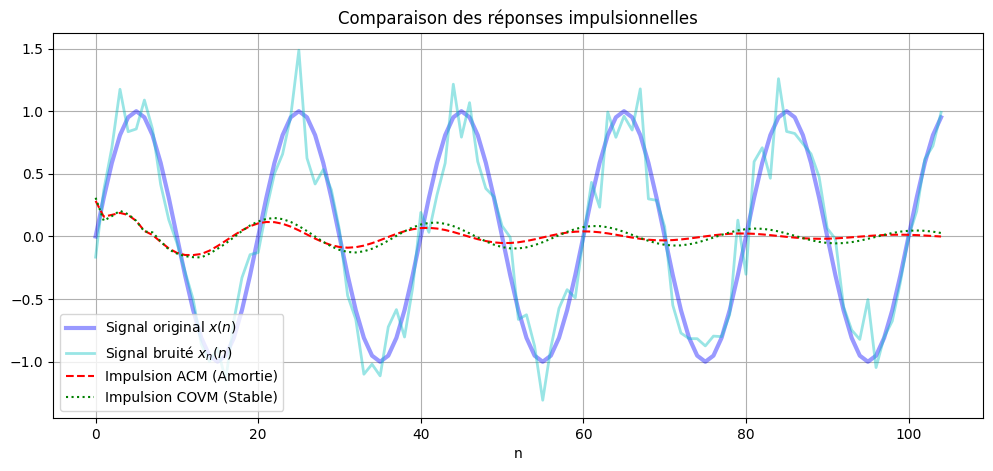

In [9]:
# Réponses Impulsionnelles
h_acm_n = signal.lfilter(bq_acm_n, ap_acm_n, dn)
h_cov_n = signal.lfilter(bq_cov_n, ap_cov_n , dn) # Gain ajusté pour match phase/amp
plt.figure(figsize=(12, 5))
plt.plot(n, x, 'b', label="Signal original $x(n)$", alpha=0.4, linewidth=3)
plt.plot(n, xn, 'c', label="Signal bruité $x_n(n)$", alpha=0.4, linewidth=2)
plt.plot(n, h_acm_n, 'r--', label="Impulsion ACM (Amortie)")
plt.plot(n, h_cov_n, 'g:', label="Impulsion COVM (Stable)")
plt.title("Comparaison des réponses impulsionnelles")
plt.xlabel("n")
plt.legend()
plt.grid(True)
plt.show()

## 4.3.6. Remarques sur les résultats

**ACM — pôles attirés vers le centre :**  
Le zero-padding implicite revient à appliquer une **fenêtre rectangulaire** au signal — le signal est vu comme s'il attaquait brutalement en $n=0$ et s'éteignait en $n=N-1$. Cette discontinuité introduit un biais qui attire les pôles vers l'intérieur du cercle unité, transformant la sinusoïde pure en sinusoïde amortie. Plus $N$ s'éloigne d'un multiple de $N_0$, plus ce biais est sévère.

**COVM — pôles proches du cercle unité :**  
En travaillant uniquement sur les données disponibles sans zero-padding, la COVM évite ce biais de fenêtrage. C'est la méthode à privilégier pour l'**estimation précise de fréquences pures** sur des enregistrements courts, particulièrement quand $N$ n'est pas un multiple de la période.

**Bruit — augmentation de l'ordre à $p=6$ :**  
En sur-paramétrisant le modèle, les pôles supplémentaires absorbent la contribution spectrale du bruit blanc. Les deux pôles dominants (proches du cercle unité) convergent vers la vraie fréquence $f_0$, tandis que les pôles parasites se répartissent à l'intérieur du cercle unité à des positions peu significatives.

> **Règle pratique :** En présence de bruit, choisir $p > 2$ et identifier les pôles dominants ($|z_i|$ les plus proches de 1) comme les composantes sinusoïdales du signal.